In [1]:
#Creatong the dataset
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X / 255.0

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, train_size=8000, test_size=4000, random_state=42, stratify=y
)

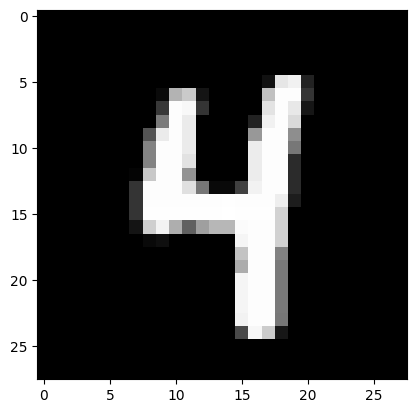

In [4]:
plt.imshow(X_train[1005].reshape(28, 28), cmap="gray")

In [5]:
#Q1
#Creating two models one linear SVM and another RBF Kernel 
from sklearn.svm import SVC
import time
from sklearn.metrics import accuracy_score,confusion_matrix


linSVC = SVC(kernel="linear",random_state=42)
rbfSVC = SVC(kernel="rbf",random_state=42)

In [6]:
#Doing for Linear SVC
start_time = time.time()
linSVC.fit(X_train,y_train)
end_time = time.time()

print(f"The Traning time for Linear SVC is {end_time-start_time}")

start_time_pred = time.time()
y_train_pred_linear = linSVC.predict(X_train)
end_time_pred = time.time()

print(f"The Prediction time for Linear SVC is {end_time_pred-start_time_pred}")

train_accuracy = accuracy_score(y_train, y_train_pred_linear)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

y_test_pred_linear = linSVC.predict(X_test)

train_accuracy = accuracy_score(y_test, y_test_pred_linear)
print(f"Test Accuracy: {train_accuracy * 100:.2f}%")

The Traning time for Linear SVC is 3.5679006576538086
The Prediction time for Linear SVC is 6.197359561920166
Training Accuracy: 99.79%
Test Accuracy: 91.42%


In [7]:
#Do the same for RBF Kernel
start_time = time.time()
rbfSVC.fit(X_train,y_train)
end_time = time.time()

print(f"The Traning time for RBF SVC is {end_time-start_time}")

start_time_pred = time.time()
y_train_pred_RBF = rbfSVC.predict(X_train)
end_time_pred = time.time()

print(f"The Prediction time for RBF SVC is {end_time_pred-start_time_pred}")

train_accuracy = accuracy_score(y_train, y_train_pred_RBF)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

y_test_pred_RBF = rbfSVC.predict(X_test)

train_accuracy = accuracy_score(y_test, y_test_pred_RBF)
print(f"Test Accuracy: {train_accuracy * 100:.2f}%")

The Traning time for RBF SVC is 6.242755889892578
The Prediction time for RBF SVC is 16.254039525985718
Training Accuracy: 98.36%
Test Accuracy: 95.23%


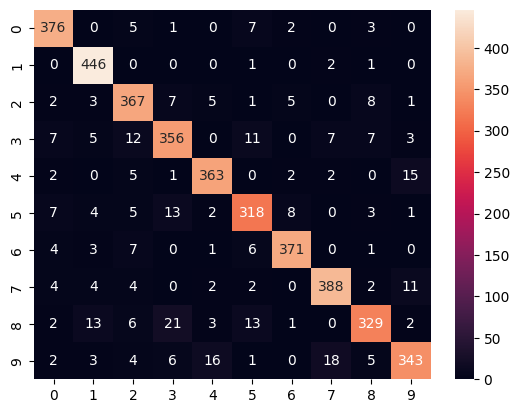

In [8]:
import seaborn as sns
sns.heatmap(confusion_matrix(y_test,y_test_pred_linear),annot=True,fmt="d")
plt.show()


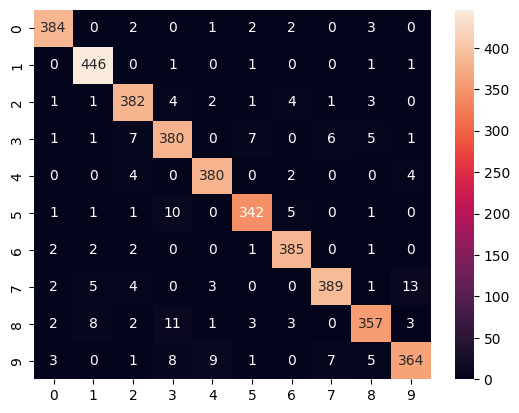

In [9]:
sns.heatmap(confusion_matrix(y_test,y_test_pred_RBF),annot=True,fmt="d")
plt.show()

In [10]:
#Q2
C = [0.01,0.1,1,10,10]
train_acc = []
test_acc = []
num_support_vec = []

for c_val in C:
    rbfSVC = SVC(C=c_val,kernel="rbf")

    start_time = time.time()
    rbfSVC.fit(X_train,y_train)
    end_time = time.time()
    
    print(f"The Traning time for RBF SVC with {c_val} C value is {end_time-start_time}")
    
    y_train_pred_RBF = rbfSVC.predict(X_train)

    train_accuracy = accuracy_score(y_train, y_train_pred_RBF)
    print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
    
    y_test_pred_RBF = rbfSVC.predict(X_test)
    
    test_accuracy = accuracy_score(y_test, y_test_pred_RBF)
    print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

    print(f"Total support vectors is {len(rbfSVC.support_)}")
    train_acc.append(train_accuracy)
    test_acc.append(test_accuracy)
    num_support_vec.append(len(rbfSVC.support_))
    print()

The Traning time for RBF SVC with 0.01 C value is 42.211546421051025
Training Accuracy: 72.90%
Test Accuracy: 72.75%
Total support vectors is 7806

The Traning time for RBF SVC with 0.1 C value is 15.386619091033936
Training Accuracy: 93.71%
Test Accuracy: 92.12%
Total support vectors is 5344

The Traning time for RBF SVC with 1 C value is 7.778273582458496
Training Accuracy: 98.36%
Test Accuracy: 95.23%
Total support vectors is 3317

The Traning time for RBF SVC with 10 C value is 7.524966478347778
Training Accuracy: 99.99%
Test Accuracy: 96.55%
Total support vectors is 3283

The Traning time for RBF SVC with 10 C value is 7.32482385635376
Training Accuracy: 99.99%
Test Accuracy: 96.55%
Total support vectors is 3283



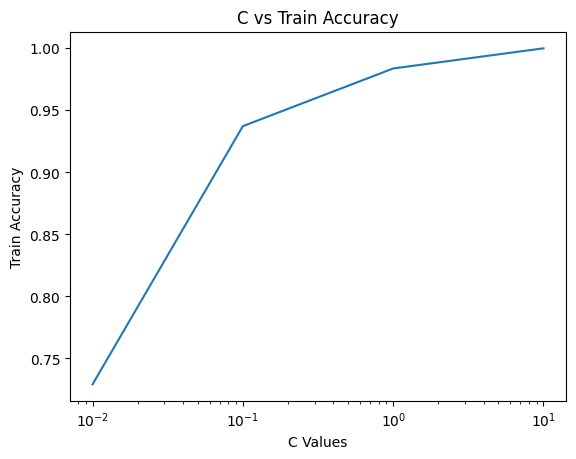

In [16]:
plt.semilogx(C,train_acc)
plt.xlabel("C Values")
plt.ylabel("Train Accuracy")
plt.title("C vs Train Accuracy")
plt.show()

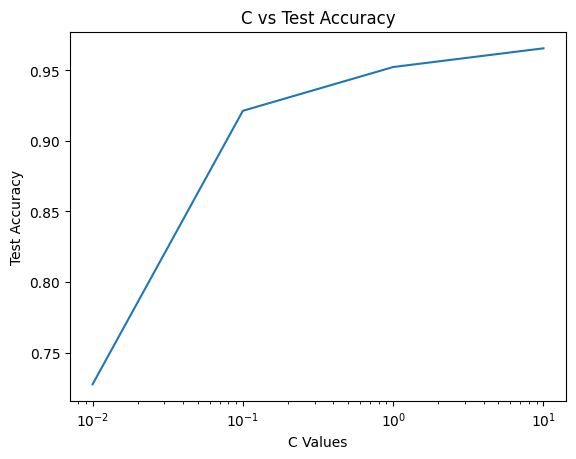

In [17]:
plt.semilogx(C,test_acc)
plt.xlabel("C Values")
plt.ylabel("Test Accuracy")
plt.title("C vs Test Accuracy")
plt.show()

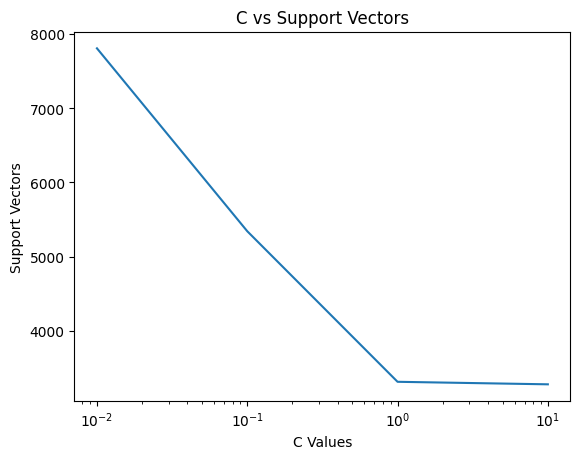

In [18]:
plt.semilogx(C,num_support_vec)
plt.xlabel("C Values")
plt.ylabel("Support Vectors")
plt.title("C vs Support Vectors")
plt.show()

In [20]:
#Q3
gamma = [10**-4,10**-3,10**-2,10**-1]
train_acc = []
test_acc = []
num_support_vec = []

for gamma_val in gamma:
    rbfSVC = SVC(C=1,kernel="rbf",gamma=gamma_val)

    start_time = time.time()
    rbfSVC.fit(X_train,y_train)
    end_time = time.time()
    
    print(f"The Traning time for RBF SVC with {gamma_val} C value is {end_time-start_time}")
    
    y_train_pred_RBF = rbfSVC.predict(X_train)

    train_accuracy = accuracy_score(y_train, y_train_pred_RBF)
    print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
    
    y_test_pred_RBF = rbfSVC.predict(X_test)
    
    test_accuracy = accuracy_score(y_test, y_test_pred_RBF)
    print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

    print(f"Total support vectors is {len(rbfSVC.support_)}")
    train_acc.append(train_accuracy)
    test_acc.append(test_accuracy)
    num_support_vec.append(len(rbfSVC.support_))
    print()

The Traning time for RBF SVC with 0.0001 C value is 25.748926877975464
Training Accuracy: 83.95%
Test Accuracy: 83.43%
Total support vectors is 7374

The Traning time for RBF SVC with 0.001 C value is 11.403998136520386
Training Accuracy: 91.91%
Test Accuracy: 90.75%
Total support vectors is 4814

The Traning time for RBF SVC with 0.01 C value is 5.852319240570068
Training Accuracy: 97.61%
Test Accuracy: 94.75%
Total support vectors is 3225

The Traning time for RBF SVC with 0.1 C value is 36.112138509750366
Training Accuracy: 100.00%
Test Accuracy: 86.42%
Total support vectors is 7050



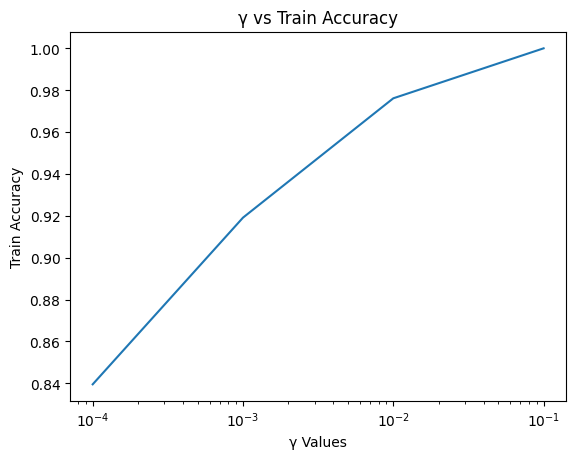

In [26]:
plt.semilogx(gamma,train_acc)
plt.xlabel("γ Values")
plt.ylabel("Train Accuracy")
plt.title("γ vs Train Accuracy")
plt.show()

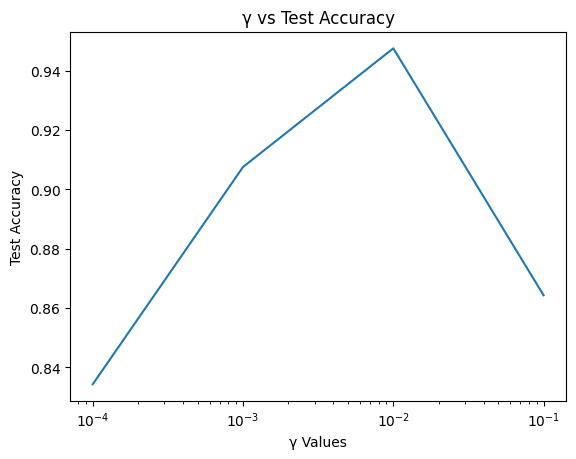

In [27]:
plt.semilogx(gamma,test_acc)
plt.xlabel("γ Values")
plt.ylabel("Test Accuracy")
plt.title("γ vs Test Accuracy")
plt.show()

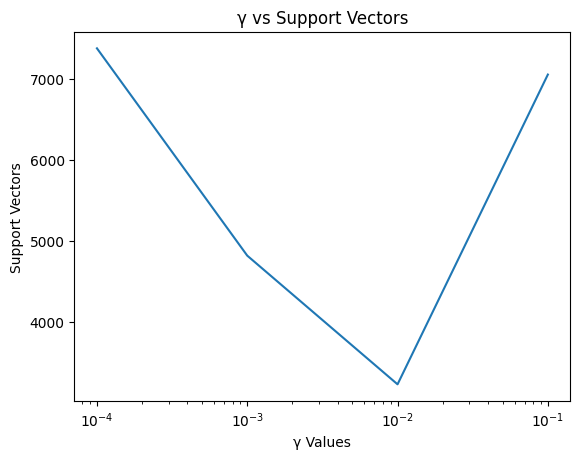

In [29]:
plt.semilogx(gamma,num_support_vec)
plt.xlabel("γ Values")
plt.ylabel("Support Vectors")
plt.title("γ vs Support Vectors")
plt.show()

In [ ]:
#Q4
#Comparing the Accuracy Score of both Logistic Regresison and SVM

#The accuracy score of Logistic Regression with default parameters was 90.8%
#Whereas for accuracy_score for SVC with default parameteras was 91.4%

#SVM outperforms Logisitc Regression in non linear data transformation  using kernels 
#Logistic Regression outperforms in linear data  and faster traning times and is prone to overfitting 
#especially in higher dimesnsions


In [ ]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X / 255.0

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, train_size=200, test_size=10, random_state=42, stratify=y
)

In [30]:
#Q5
rbfSVC = SVC(kernel="rbf", gamma=10**-2,C=0.1)
rbfSVC.fit(X_train, y_train)

SVC(C=0.1, gamma=0.01)

In [42]:
support_vectors = rbfSVC.support_vectors_
labels = rbfSVC.support_
print(f"Total number of support vectors: {len(support_vectors)}")
print(labels)

Total number of support vectors: 5459
[  40   44   49 ... 7927 7929 7983]


In [39]:
support_vectors.shape

(5459, 784)

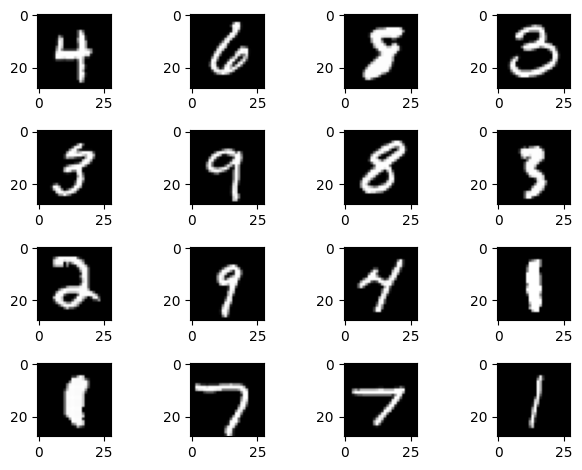

In [69]:
import numpy as np
random_values = np.random.choice(len(support_vectors), size=16)

fig, ax = plt.subplots(4, 4)

for idx, pic_index in enumerate(random_values):
    row = idx // 4
    col = idx % 4
    
    ax[row, col].imshow(support_vectors[pic_index].reshape(28, 28), cmap='gray')

plt.tight_layout()
plt.show()